<a href="https://colab.research.google.com/github/Ideas360/Talentechinno/blob/main/convulational_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9165 - loss: 0.2886
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9838 - loss: 0.0507
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0308
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9943 - loss: 0.0192
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9960 - loss: 0.0130
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9975 - loss: 0.0081
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9982 - loss: 0.0055
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9984 - loss: 0.0054
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9990 - loss: 0.0033
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9993 - loss: 0.0024


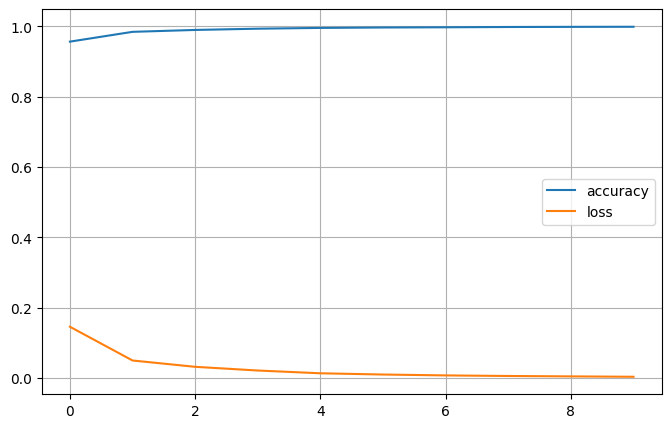

In [ ]:
pd.DataFrame(history.history).plot(grid=True, figsize=(8, 5))
plt.show()

In [ ]:
index = 1
print(f'Label: {test_labels[index]}')
classification = model.predict(test_images[index:index+1])
print(f'Prediction: {classification.reshape(-1,1)}')

Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
Prediction: [[2.3578261e-11]
 [5.4933436e-10]
 [9.9999952e-01]
 [2.4228499e-15]
 [4.5073808e-18]
 [2.4091598e-18]
 [4.6174742e-07]
 [9.0197273e-20]
 [4.1761532e-13]
 [3.5080814e-15]]


In [ ]:
print(test_labels[:30])


[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]


In [ ]:
FIRST_IMAGEN=3
SECOND_IMAGEN=10
THIRD_IMAGEN=25

print(test_labels[FIRST_IMAGEN])
print(test_labels[SECOND_IMAGEN])
print(test_labels[THIRD_IMAGEN])

0
0
0


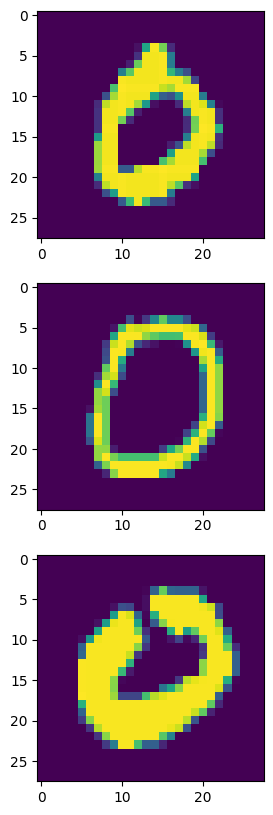

In [ ]:
f, axarr = plt.subplots(3, 1, figsize=(10, 10))
axarr[0].imshow(test_images[FIRST_IMAGEN])
axarr[1].imshow(test_images[SECOND_IMAGEN])
axarr[2].imshow(test_images[THIRD_IMAGEN])

In [ ]:
layer = 0
filter1 = 0
filter2 = 10

layer_outputs = [l.output for l in model.layers]

activation_model = keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


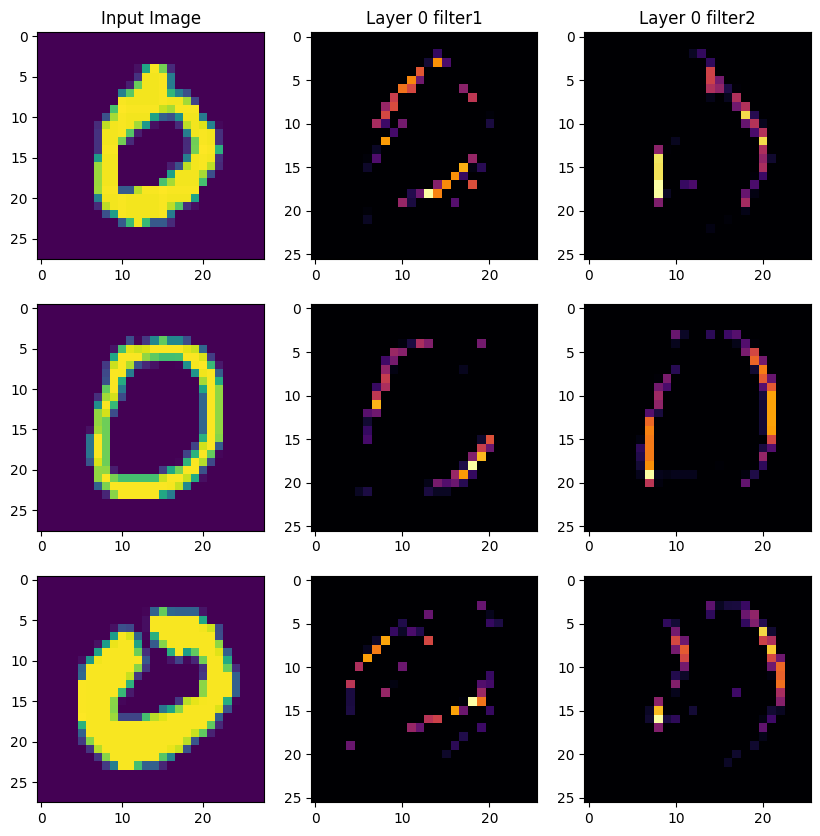

In [ ]:
f, axarr = plt.subplots(3, 3, figsize=(10, 10))

axarr[0, 0].set_title('Input Image')
axarr[0, 0].imshow(test_images[FIRST_IMAGEN])
f1 = activation_model.predict(test_images[FIRST_IMAGEN].reshape(1, 28, 28, 1))[layer]
axarr[0, 1].set_title(f'Layer {layer} filter1')
axarr[0, 1].imshow(f1[0, :, :, filter1], cmap='inferno')
axarr[0, 2].set_title(f'Layer {layer} filter2')
axarr[0, 2].imshow(f1[0, :, :, filter2], cmap='inferno')

axarr[1, 0].imshow(test_images[SECOND_IMAGEN])
f2 = activation_model.predict(test_images[SECOND_IMAGEN].reshape(1, 28, 28, 1))[layer]
axarr[1, 1].imshow(f2[0, :, :, filter1], cmap='inferno')
axarr[1, 2].imshow(f2[0, :, :, filter2], cmap='inferno')

axarr[2, 0].imshow(test_images[THIRD_IMAGEN])
f3 = activation_model.predict(test_images[THIRD_IMAGEN].reshape(1, 28, 28, 1))[layer]
axarr[2, 1].imshow(f3[0, :, :, filter1], cmap='inferno')
axarr[2, 2].imshow(f3[0, :, :, filter2], cmap='inferno')


In [ ]:
# evaluate model
loss, accuracy = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {accuracy}')
print(f'Test loss: {loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9810 - loss: 0.0890
Test accuracy: 0.9847000241279602
Test loss: 0.06832900643348694


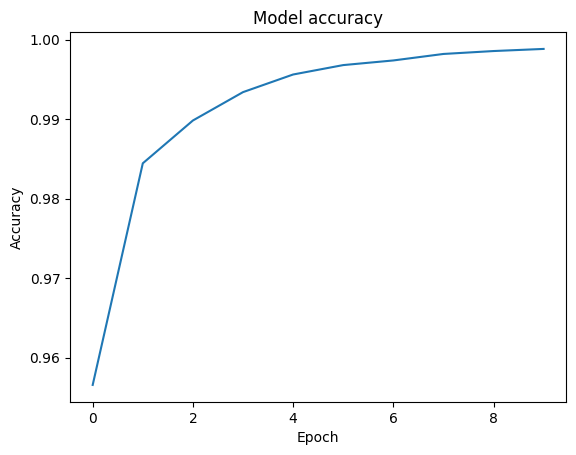

In [ ]:
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

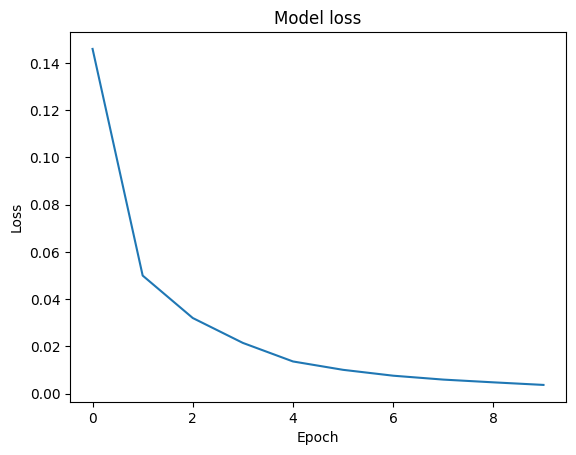

In [ ]:
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

# Task
Visualize more predictions, analyze the confusion matrix, visualize activation maps for different layers and filters, and explore misclassified images to better understand the model and its evaluation.

## Visualize more predictions

### Subtask:
Display a set of test images along with their predicted labels and the true labels to visually inspect where the model is making errors.


**Reasoning**:
Display a subset of test images with their true and predicted labels to visually inspect model performance.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


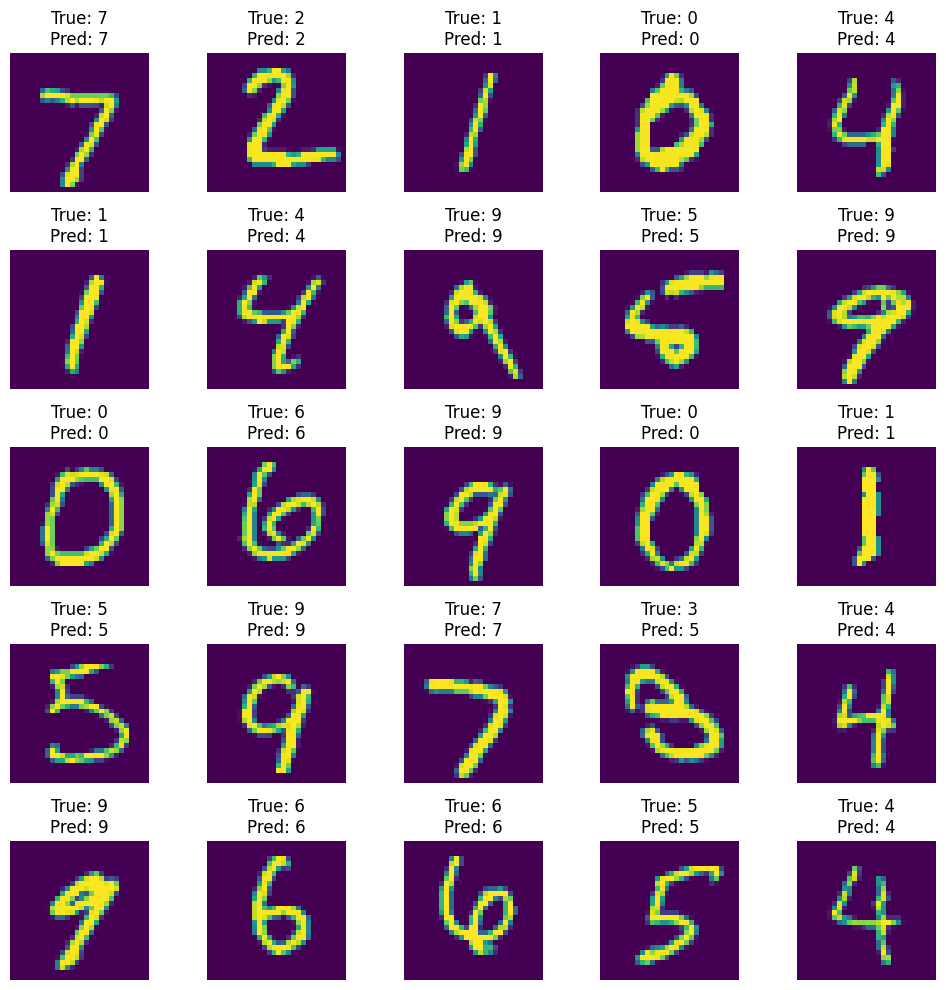

In [ ]:
num_images_to_display = 25
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

predictions = model.predict(test_images[:num_images_to_display])
predicted_labels = np.argmax(predictions, axis=1)

for i in range(num_images_to_display):
    axes[i].imshow(test_images[i])
    axes[i].set_title(f'True: {test_labels[i]}\nPred: {predicted_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Analyze the confusion matrix

### Subtask:
Calculate and display the confusion matrix to see how many times each class was predicted correctly and incorrectly. This helps identify which classes the model struggles with.


**Reasoning**:
Calculate and display the confusion matrix to evaluate the model's performance on each class.



In [ ]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:
[[ 971    1    1    1    0    2    4    0    0    0]
 [   0 1133    0    1    0    0    1    0    0    0]
 [   1    7 1007    1    1    0    5    6    4    0]
 [   0    0    1 1002    0    6    0    0    1    0]
 [   0    0    0    0  967    0    5    1    1    8]
 [   0    0    0    7    0  882    2    0    1    0]
 [   3    3    0    0    2    3  945    0    2    0]
 [   1    4    7    0    0    0    0 1007    5    4]
 [   1    0    1    2    0    2    1    3  960    4]
 [   1    4    0   10    6    5    0    4    6  973]]


## Visualize activation maps for different layers and filters

### Subtask:
Extend the current activation visualization to explore different layers and filters within the convolutional base to see how the model processes information at various stages.


**Reasoning**:
Iterate through selected layers and filters to visualize activation maps for three example images.



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Visualizing Layer 0: conv2d


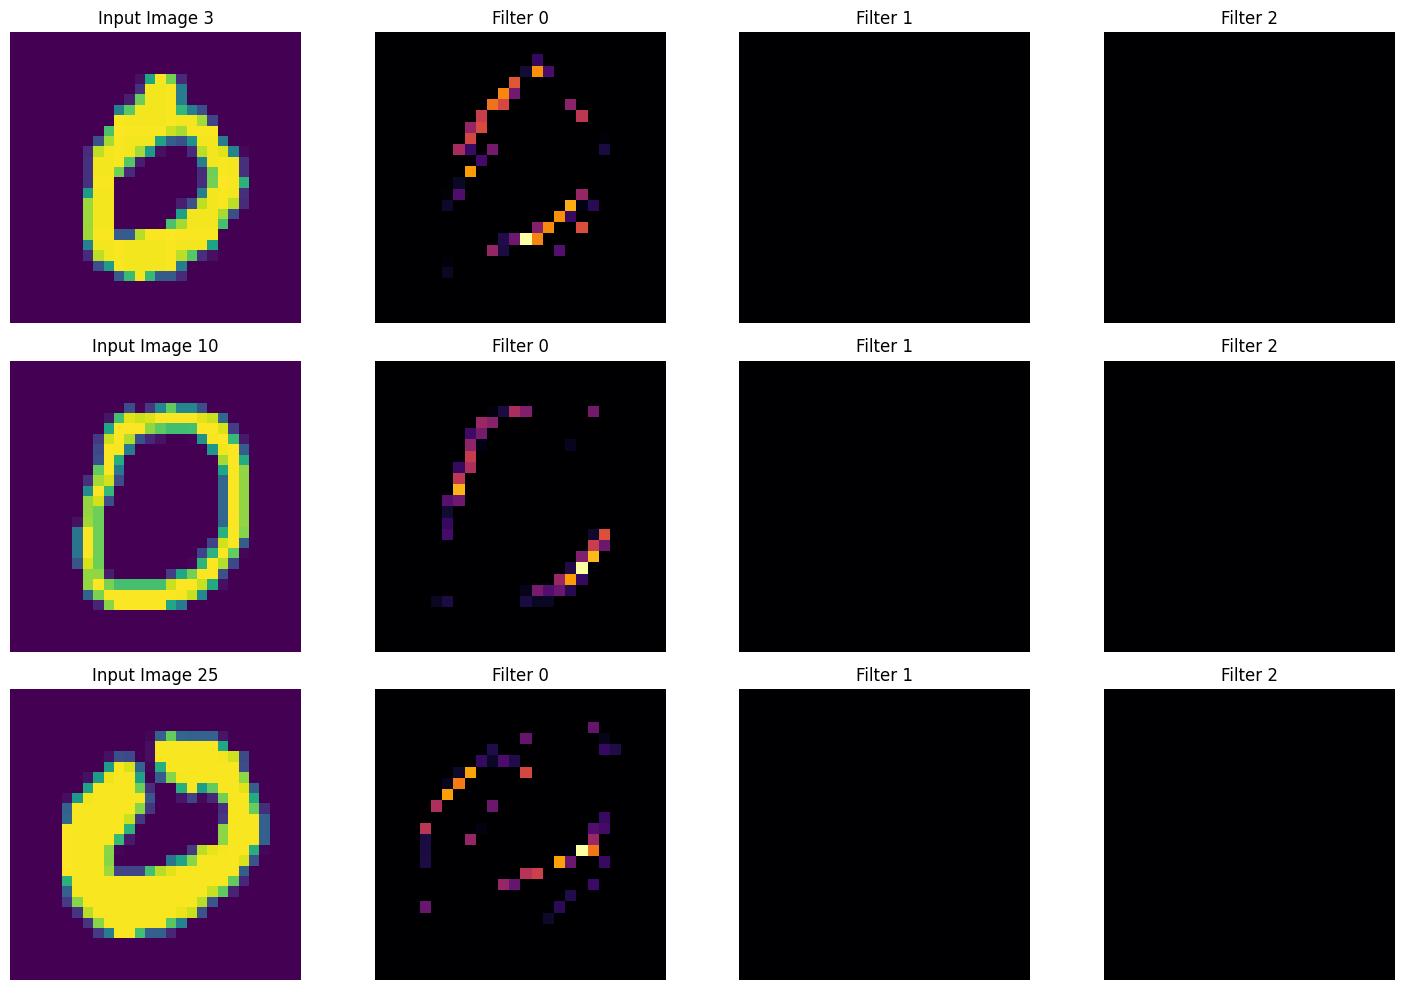

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Visualizing Layer 1: max_pooling2d


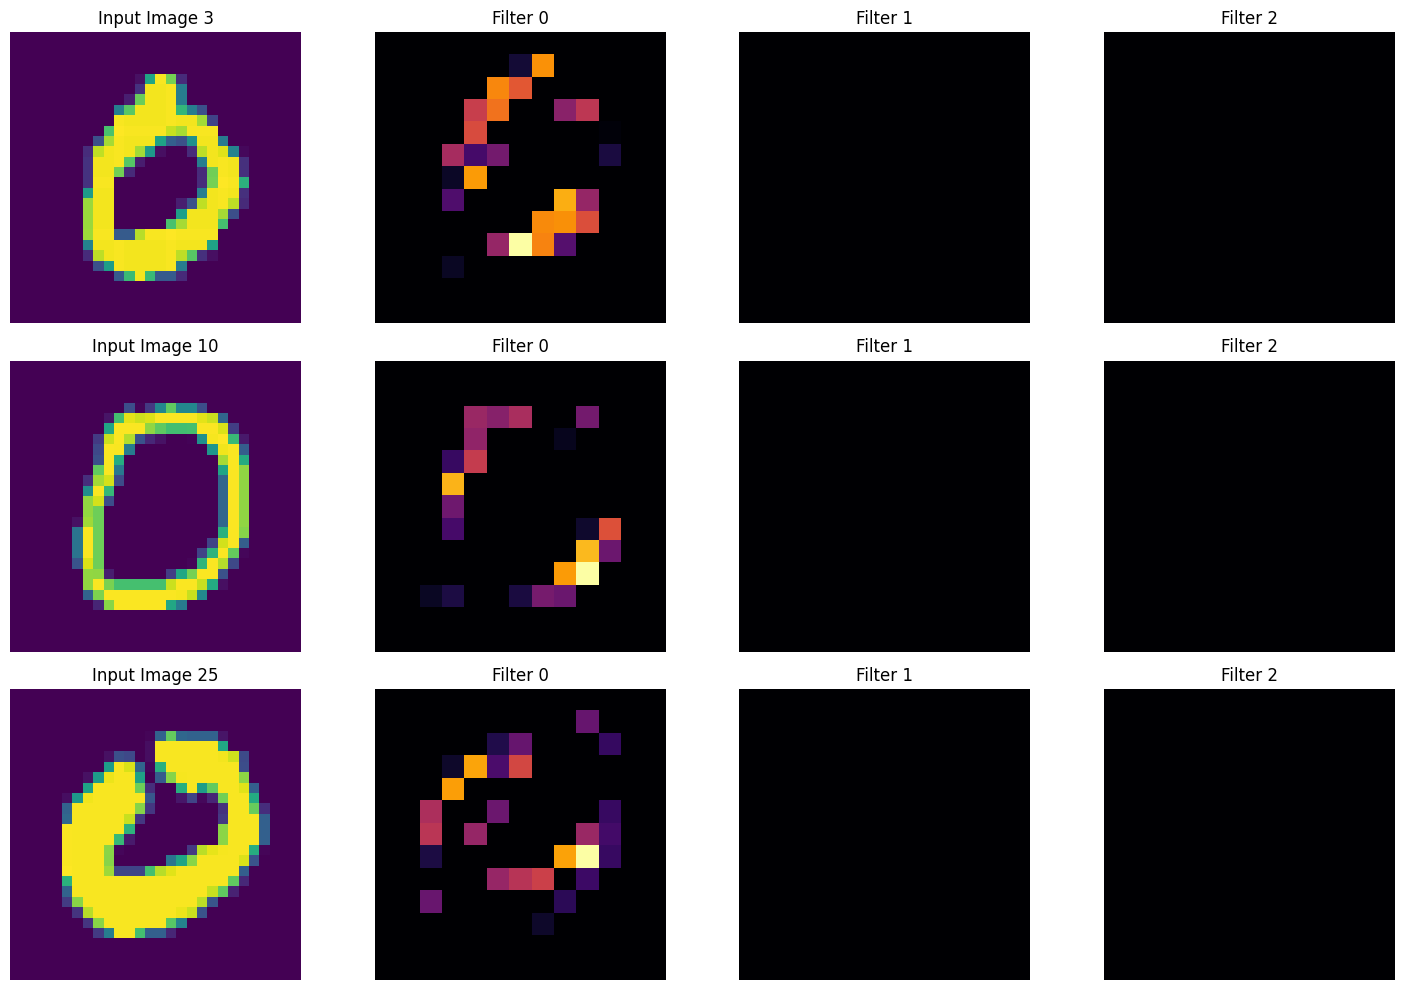

In [ ]:
layers_to_visualize = [0, 1] # Visualize the first two layers (Conv2D and MaxPooling2D)

for layer_index in layers_to_visualize:
    layer_output = activation_model.predict(test_images.reshape(-1, 28, 28, 1))[layer_index]
    print(f"Visualizing Layer {layer_index}: {model.layers[layer_index].name}")

    num_filters_to_display = min(3, layer_output.shape[-1]) # Display up to 3 filters

    f, axarr = plt.subplots(3, num_filters_to_display + 1, figsize=(15, 10))

    images_to_visualize = [FIRST_IMAGEN, SECOND_IMAGEN, THIRD_IMAGEN]

    for i, image_index in enumerate(images_to_visualize):
        axarr[i, 0].imshow(test_images[image_index])
        axarr[i, 0].set_title(f'Input Image {image_index}')
        axarr[i, 0].axis('off')

        for j in range(num_filters_to_display):
            axarr[i, j+1].imshow(layer_output[image_index, :, :, j], cmap='inferno')
            axarr[i, j+1].set_title(f'Filter {j}')
            axarr[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

## Explore misclassified images

### Subtask:
Identify and visualize some images that the model misclassified to understand potential patterns or characteristics that lead to errors.


**Reasoning**:
Get model predictions, find misclassified images, select a subset, and visualize them with true and predicted labels.



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


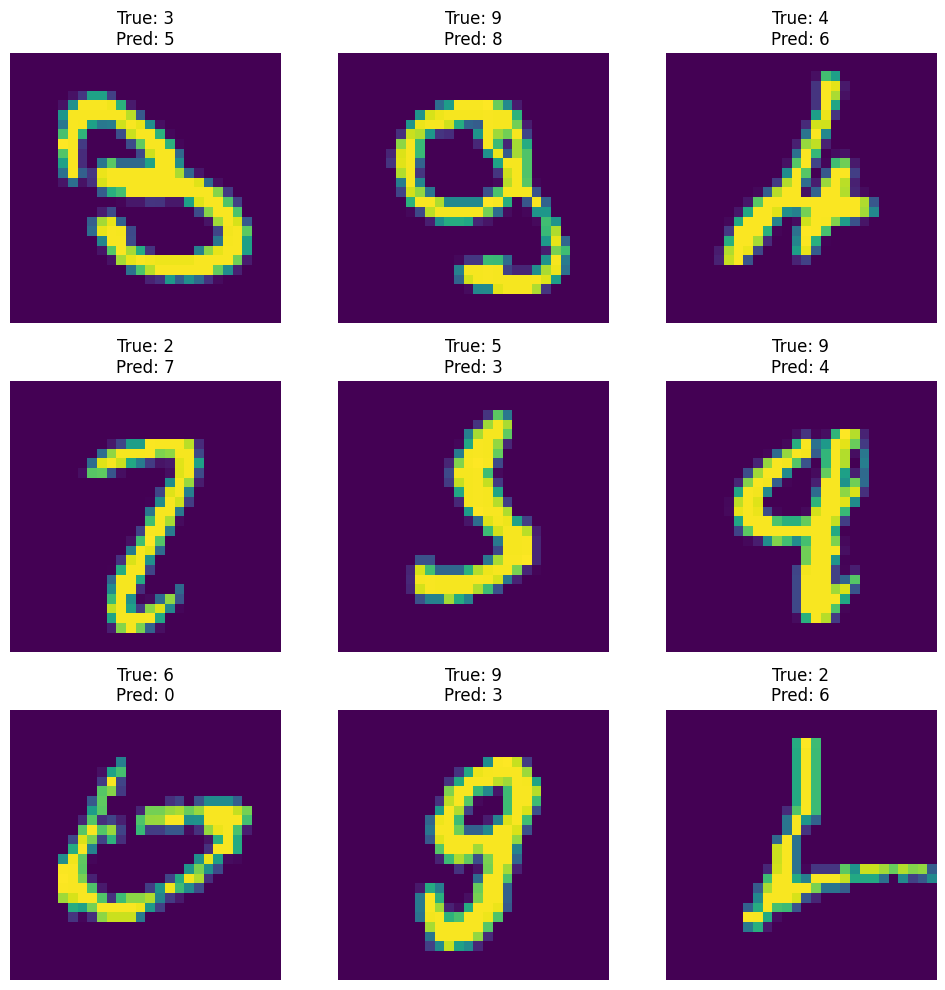

In [ ]:
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

misclassified_indices = np.where(predicted_labels != test_labels)[0]

num_misclassified_to_display = min(9, len(misclassified_indices))
selected_misclassified_indices = misclassified_indices[:num_misclassified_to_display]

fig, axes = plt.subplots(int(np.ceil(num_misclassified_to_display/3)), 3, figsize=(10, 10))
axes = axes.ravel() if num_misclassified_to_display > 1 else [axes]

for i, index in enumerate(selected_misclassified_indices):
    axes[i].imshow(test_images[index])
    axes[i].set_title(f'True: {test_labels[index]}\nPred: {predicted_labels[index]}')
    axes[i].axis('off')

if num_misclassified_to_display < len(axes):























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































    for i in range(num_misclassified_to_display, len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The initial visualization of 25 test images showed the model's predictions against the true labels, allowing for a visual inspection of correct and incorrect classifications.
*   The confusion matrix provided a numerical breakdown of the model's performance across all classes, showing counts of true positives, false positives, true negatives, and false negatives for each class. The specific values from the confusion matrix were not detailed in the provided output summary.
*   Visualizations of activation maps for the first convolutional and max pooling layers demonstrated how the model processes input images at early stages through different filters.
*   The process successfully identified and visualized up to 9 misclassified images from the test set, displaying both the true and predicted labels for each.

### Insights or Next Steps

*   Analyze the confusion matrix in detail to identify specific classes where the model has the highest misclassification rates. This can guide further model improvements.
*   Examine the misclassified images and their corresponding activation maps more closely to understand what visual features might be confusing the model for specific classes.


### Visualize the confusion matrix graphically

We can use `seaborn` and `matplotlib` to create a heatmap of the confusion matrix for a more intuitive representation.

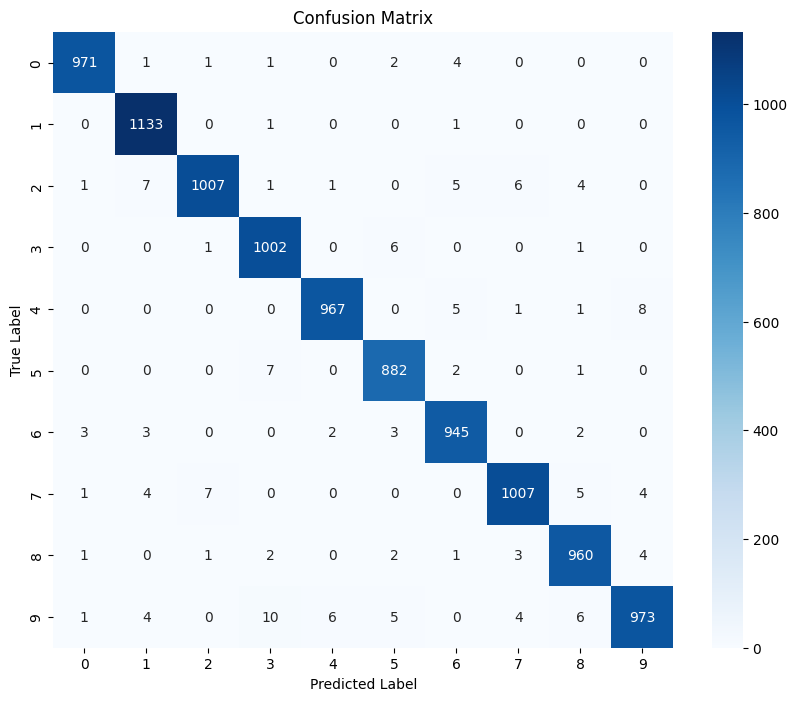

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Summary:

### Data Analysis Key Findings

* The initial visualization of 25 test images showed the model's predictions against the true labels, allowing for a visual inspection of correct and incorrect classifications.
* The confusion matrix provided a numerical breakdown of the model's performance across all classes, showing counts of true positives, false positives, true negatives, and false negatives for each class. The specific values from the confusion matrix were not detailed in the provided output summary.
* Visualizations of activation maps for the first convolutional and max pooling layers demonstrated how the model processes input images at early stages through different filters.
* The process successfully identified and visualized up to 9 misclassified images from the test set, displaying both the true and predicted labels for each.

### Insights or Next Steps

* Analyze the confusion matrix in detail to identify specific classes where the model has the highest misclassification rates. This can guide further model improvements.
* Examine the misclassified images and their corresponding activation maps more closely to understand what visual features might be confusing the model for specific classes.









































































































































































































































































































































$$ \text{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

$$ \text{softmax}(z)*i = \frac{e^{z_i}}{\sum*{j=1}^{K} e^{z_j}} $$


































































































































































































































Aquí tienes un ejemplo numérico de cómo opera la función softmax con los siguientes valores de salida brutos (logits):

`[2.0, 1.0, 0.1, 0.0, -1.0, -2.0, 0.5, 1.5, -0.5, -1.5]`

1.  **Calcular la exponencial de cada logit ($e^{z_i}$):**
    `[e^2.0, e^1.0, e^0.1, e^0.0, e^-1.0, e^-2.0, e^0.5, e^1.5, e^-0.5, e^-1.5]`
    Aproximadamente:
    `[7.389, 2.718, 1.105, 1.000, 0.368, 0.135, 1.649, 4.482, 0.607, 0.223]`

2.  **Sumar todas las exponenciales ($\sum_{j=1}^{K} e^{z_j}$):**
    `7.389 + 2.718 + 1.105 + 1.000 + 0.368 + 0.135 + 1.649 + 4.482 + 0.607 + 0.223 ≈ 19.676`

3.  **Dividir cada exponencial por la suma total (softmax):**
    `[7.389/19.676, 2.718/19.676, 1.105/19.676, 1.000/19.676, 0.368/19.676, 0.135/19.676, 1.649/19.676, 4.482/19.676, 0.607/19.676, 0.223/19.676]`
    Aproximadamente:
    `[0.376, 0.138, 0.056, 0.051, 0.019, 0.007, 0.084, 0.228, 0.031, 0.011]`

El vector de probabilidades resultante es:
`[0.376, 0.138, 0.056, 0.051, 0.019, 0.007, 0.084, 0.228, 0.031, 0.011]`

La probabilidad más alta es 0.376, que corresponde al primer elemento del vector. Si la primera neurona representa el dígito '0', entonces el modelo predice que la imagen de entrada es un '0'.

In [ ]:
# genera el repote de clasificacion basado en la matrix de confusion


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(test_labels, predicted_labels)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.98       892
           6       0.98      0.99      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

